In [2]:
import pandas as pd
import requests

In [1]:
import sys
import os

# Obtener la ruta absoluta de la carpeta 'notebooks'
notebook_dir = os.getcwd()

# Subir un nivel para llegar a la raíz del proyecto ('cuentas')
project_root = os.path.dirname(notebook_dir)

# Añadir la raíz del proyecto a la ruta de búsqueda de Python
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Source

In [35]:
from contabilidad.backend.data_pipeline import get_pipeline, reset_pipeline

from contabilidad.backend.routes.dashboard import DashboardService

In [54]:
ds = DashboardService()
data= ds.get_chart_data()
data

INFO:contabilidad.backend.routes.dashboard:Fetching data from BankDataSource
INFO:contabilidad.backend.routes.dashboard:Fetching data from CardDataSource
INFO:contabilidad.backend.routes.dashboard:Fetching data from SupabaseDebtDataSource


⚙ Loading: banca_data from XLSX
⚙ Loading: cuenta_data from Unified Banca Source
✓ Cache hit: banca_data
✓ Cache hit: inversiones
✓ Cache hit: tarjetas


DashboardResponse(data=[ChartDataPoint(date='2024-09-20', total=-252.36677419354797, saldo=10205.27, saldo_sin_inversion=-280.72999999999956, tarjeta=-52.54000000000002, pagos_fijos=10486.0, interpolado=80.90322580645162, notion=0.0, deuda_acumulada=0.0, diff_total=0.0, diff_tarjeta=0.0, diff_saldo_sin_inversion=0.0, diff_notion=0.0, diff_deuda_acumulada=0.0, diff_pagos_fijos=0.0, diff_interpolados=0.0), ChartDataPoint(date='2024-09-21', total=-248.10870967741894, saldo=10205.27, saldo_sin_inversion=-280.72999999999956, tarjeta=-52.54000000000002, pagos_fijos=10486.0, interpolado=85.16129032258064, notion=0.0, deuda_acumulada=0.0, diff_total=4.258064516129025, diff_tarjeta=0.0, diff_saldo_sin_inversion=0.0, diff_notion=0.0, diff_deuda_acumulada=0.0, diff_pagos_fijos=0.0, diff_interpolados=4.258064516129025), ChartDataPoint(date='2024-09-22', total=-243.85064516128992, saldo=10205.27, saldo_sin_inversion=-280.72999999999956, tarjeta=-52.54000000000002, pagos_fijos=10486.0, interpolado=8

In [64]:
pd.DataFrame([(dia.date,dia.diff_saldo_sin_inversion,dia.diff_tarjeta, dia.diff_total,dia.tarjeta, dia.saldo_sin_inversion,dia.saldo, dia.total) for dia in data.data if dia.date > "2025-06-20" and dia.date < "2025-06-26"],columns=["date","diff_saldo_sin_inversion","diff_tarjeta","diff_total","tarjeta","saldo_sin_inversion","saldo","total"])

,date,diff_saldo_sin_inversion,diff_tarjeta,diff_total,tarjeta,saldo_sin_inversion,saldo,total
0,2025-06-21,0.00,0.00,3.125,-381.73,-78.76,39064.24,-369.865
1,2025-06-22,0.00,0.00,3.125,-381.73,-78.76,39064.24,-366.740
2,2025-06-23,-30.20,167.33,140.255,-214.40,-108.96,39034.04,-226.485
3,2025-06-24,-164.94,0.00,-261.815,-214.40,-273.90,38869.10,-488.300
4,2025-06-25,-10.00,0.00,-10.000,-214.40,-283.90,38859.10,-498.300


In [42]:
[data for data in data.data if data.date=="2025-01-06"]

[ChartDataPoint(date='2025-01-06', total=209.40999999999968, saldo=499.79, saldo_sin_inversion=499.79, tarjeta=-290.38000000000034, pagos_fijos=0.0, interpolado=0.0, notion=0.0, deuda_acumulada=0.0, diff_total=438.35, diff_tarjeta=0.0, diff_saldo_sin_inversion=438.35, diff_notion=0.0, diff_deuda_acumulada=0.0, diff_pagos_fijos=0.0, diff_interpolados=0.0)]

In [85]:
pipeline = get_pipeline()
df_banca=pipeline.get_banca_data()

✓ Cache hit: banca_data


In [88]:
df_banca[df_banca['FECHA'] > '2025-06-19'].head(20)

,id,FECHA,DESCRIPCION,MONTO,FUENTE,SALDO
335,fbed8555962d43345825ee0913407904,2025-06-19 12:17:00,TRANSFERENCIA INTERBANCARIA A DILLAN DAVID GON...,-0.80,BANCO,39103.36
336,aa5c3567d881c0f36c34ed0653e4e026,2025-06-19 12:53:00,TRANSFERENCIA DIRECTA A SILLO MALDONADO JORGE ...,-8.50,BANCO,39094.86
337,b9727baa586045e1c3522b34d9a19cc3,2025-06-19 14:03:00,TRANSFERENCIA INTERBANCARIA A MB MAYFLOWER BUF...,-8.84,BANCO,39086.02
338,c2788ad43d890d4bb4e8c857b48bd01a,2025-06-19 14:04:00,TRANSFERENCIA INTERBANCARIA A DELI INTERNACION...,-5.99,BANCO,39080.03
339,bc6d9dab160a59cc424ac950a0fb2b51,2025-06-19 15:25:00,TRANSFERENCIA INTERBANCARIA A MINISO ECUADOR S...,-15.99,BANCO,39064.04
340,fea1cd7feef07afe5874e2fe07dd23e4,2025-06-19 16:22:00,TRANSFERENCIA INTERBANCARIA A DILLAN DAVID GON...,-0.80,BANCO,39063.24
341,166ce9815c4e93f05ab7a12098d9fcd8,2025-06-20 11:29:00,TRANSFERENCIA INTERBANCARIA DE GUSTAVO DAVID J...,3.00,BANCO,39066.24
342,ecaee2193b07d2d0d2bf9ffa5e862909,2025-06-20 12:50:00,TRANSFERENCIA INTERBANCARIA A GUSTAVO DAVID JA...,-2.00,BANCO,39064.24
343,0c3547c5b8ce9cbbfa796719df8a361b,2025-06-23 10:37:00,TRANSFERENCIA DIRECTA A LOOR BRAVO ARLETH SOLANGE,-18.74,BANCO,39015.30
344,341d66bdb72ee24e0807c5a97b9f8f77,2025-06-23 11:39:00,PAGO TARJETA: 2230670000895647,-20.00,BANCO,38995.30


In [4]:
from contabilidad.banckend.routes.transactions import load_source_data

ModuleNotFoundError: No module named 'contabilidad.banckend'

In [110]:
#fetch  const res = await axios.get(`${API_BASE}/dashboard/chart-data`);
                                                                                
API_BASE = 'http://localhost:8000/api'
res = requests.post(f"{API_BASE}/sources/bank/process")
data = res.json()
data

{'detail': 'Reindexing only valid with uniquely valued Index objects'}

In [102]:
df = pd.read_csv(PATH, encoding='utf-8',sep=";")
df

ParserError: Error tokenizing data. C error: Expected 7 fields in line 60, saw 10


In [103]:




def process_data(input_file, output_file):
    with open(input_file, 'r', encoding='utf-8') as infile, \
         open(output_file, 'w', newline='', encoding='utf-8') as outfile:
        
        reader = csv.reader(infile, delimiter=';')
        writer = csv.writer(outfile, delimiter=';')
        
        header_written = False
        
        for row in reader:
            # Ignorar líneas vacías o incompletas
            if not row or all(cell == '' for cell in row):
                continue

            # 2. ELIMINAR CELDAS VACÍAS AL FINAL (Trailing semicolons)
            # Eliminamos desde el final mientras la celda sea basura o esté vacía
            while row and (row[-1] is None or row[-1].strip() == ''):
                    row.pop()
                
            # Manejo de la cabecera
            if row[0].strip().upper() == 'FECHA':
                if not header_written:
                    writer.writerow(row)
                    header_written = True
                continue # Omitir cabeceras repetidas
                
            # Transformar la fecha
            row[0] = parse_date(row[0])
            writer.writerow(row)

if __name__ == '__main__':
    process_data('data/raw_data.csv', 'data/clean_data.csv')
    print("✅ Procesamiento completado. Revisa data/clean_data.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw_data.csv'

In [3]:
#!/usr/bin/env python3
import csv
import re
import sys
from datetime import datetime
# Mapeo universal de meses (soporta los strings de tu dataset)
MONTHS = {
    'ene': '01', 'feb': '02', 'mar': '03', 'abr': '04', 'may': '05', 'jun': '06',
    'jul': '07', 'ago': '08', 'sep': '09', 'oct': '10', 'nov': '11', 'dic': '12'
}
FECHA_FORMAT: str = "%Y-%m-%d, %I:%M %p"

In [4]:
PATH = "/home/sebas/dev/projects/ContabilidadPersonal/data/cuentas/Unido.csv"
output = "/home/sebas/dev/projects/ContabilidadPersonal/data/cuentas/UnidoLimpio.csv"

In [5]:

def parse_date(date_str):
    """Parsea formatos mixtos y devuelve YYYY-MM-DD"""
    date_str = date_str.strip().lower()
    
    # Expresión regular para atrapar: DD-MMM, DD-MMM-YY, DD-MMM-YYYY
    match = re.match(r'^(\d{1,2})-([a-z]{3})(?:-(\d{4}|\d{2}))?$', date_str)
    if not match:
        return date_str # Retorna intacto si no hace match (ej. cabeceras)
        
    day, month_str, year_str = match.groups()

    # print(f"Parsed: day={day}, month_str={month_str}, year_str={year_str}")
    day = day.zfill(2)
    # Programación defensiva: aseguramos que siempre sea entero
    month = str(int(MONTHS.get(month_str, 1)))
    
    # Manejo del año
    if not year_str:
        # Heurística: Si no hay año, asumimos el año actual de la trama de datos (ej. 2025)
        # Nota: Ajusta esto según el bloque de meses si es estrictamente necesario.
        year = '2025' if month in ['01'] else '2024'
    elif len(year_str) == 2:
        year = '20' + year_str
    else:
        year = year_str
    # print(f"Day: {day}, Month: {month}, Year: {year_str}")
    try:
        # Al no pasarle hora y minuto, datetime asume 00:00:00 (12:00 AM)
        dt = datetime(int(year), int(month), int(day))
        # print(f"Parsed datetime: {dt}")
        return dt.strftime(FECHA_FORMAT)
    except ValueError as e:
        # Captura errores matemáticos (ej. 29 de febrero en año no bisiesto)
        print(f"[WARNING] Fecha matemáticamente inválida omitida: {date_str} - {e}", file=sys.stderr)
        return date_str
        


In [6]:
from contabilidad.cuenta.lectura.cuenta import leer_cuenta_csv
from contabilidad.cuenta.lectura.FileProcessingConfig import FileProcessingConfig   
from contabilidad.cuenta.validacion import probar_validez_saldo                                                                                                                                          

PATH ACTUAL: /home/sebas/dev/projects/ContabilidadPersonal/notebooks


In [15]:
new_file_config = FileProcessingConfig(path=output, tiene_monto=False, saldo_col="SALDO",fecha_col="FECHA", descripcion_col="DESCRIPCION")
# df =pd.read_csv(new_file_config.path, encoding='utf-8')
df=leer_cuenta_csv(new_file_config)
df = df[df["FECHA"]< "2024-12-01"]

Archivo CSV limpiado, primeras filas:
                  FECHA  OFIC.     N.DOC.  \
0  2024-03-11, 12:00 AM     12   57169215   
1  2024-03-11, 12:00 AM     12  111201472   
2  2024-03-11, 12:00 AM     12  196918379   
3  2024-03-11, 12:00 AM     12  213957466   
4  2024-03-12, 12:00 AM     12   49163320   

                           DESCRIPCION  DEBITO  CREDITO     SALDO  
0  TRANSFERENCIA INTERBANCARIA ENVIADA    2.50      0.0  31850.39  
1  TRANSFERENCIA INTERBANCARIA ENVIADA    2.00      0.0  31848.39  
2               TRANSFERENCIA INTERNET    9.00      0.0  31839.39  
3  TRANSFERENCIA INTERBANCARIA ENVIADA   16.00      0.0  31823.39  
4  TRANSFERENCIA INTERBANCARIA ENVIADA    3.99      0.0  31819.40  
Iniciando normalización...
Saldo normalizado, primeras filas:
                   FECHA  OFIC.     N.DOC.  \
0  2024-03-11, 12:00 AM     12   57169215   
1  2024-03-11, 12:00 AM     12  111201472   
2  2024-03-11, 12:00 AM     12  196918379   
3  2024-03-11, 12:00 AM     12  21395746

In [ ]:
#import 
ex =[('Movimientos_cuenta_20250207_20260207.xlsx', ('2025-03-24 13:10:00'), ('2026-02-06 13:37:00')), ('Movimientos_cuenta_20251101_20260111.xlsx', ('2025-11-05 12:46:00'), ('2026-01-09 18:08:00')), ('Movimientos_cuenta_20251101_20251210.xlsx', ('2025-11-05 12:46:00'), ('2025-12-09 12:13:00')), ('2024_limpio_antiguo.csv', ('2024-03-11 00:00:00'), ('2025-11-30 00:00:00')), ('Movimientos_cuenta_20250901_20251110.xlsx', ('2025-09-01 09:11:00'), ('2025-11-07 19:56:00')), ('Movimientos_cuenta_20240910_20250910.xlsx', ('2024-09-11 16:12:00'), ('2025-09-10 13:00:00'))]


In [10]:
df =df[~df["DESCRIPCION"].str.contains("INTERES", case=False, na=False)]

In [16]:
probar_validez_saldo(df)

Probando validez de saldos... con diferencia permitida de  1


In [ ]:
df[(df["FECHA"]< "2025-02-01") & (df["FECHA"]> "2024-04-01")]

<Axes: title={'center': 'Saldo a lo largo del tiempo'}, xlabel='FECHA'>

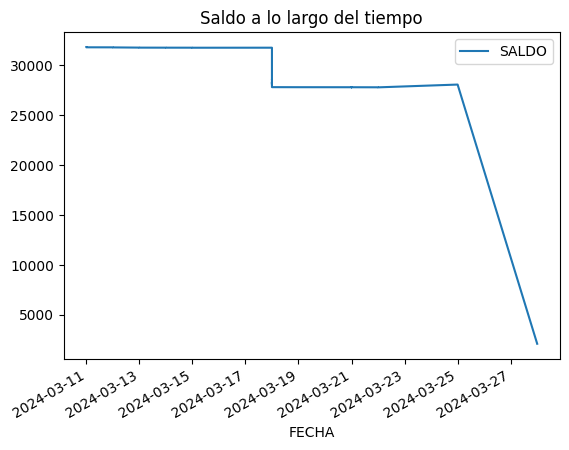

In [17]:
df.plot(x="FECHA", y="SALDO", title="Saldo a lo largo del tiempo")

In [71]:
parse_date("06-ago-2024")

Day: 06, Month: 8, Year: 2024
Parsed datetime: 2024-08-06 00:00:00


'2024-08-06, 12:00 AM'

In [45]:
with open(PATH, 'r', encoding='utf-8') as infile, \
         open(output, 'w', newline='', encoding='utf-8') as outfile:
        
        reader = csv.reader(infile, delimiter=',')
        writer = csv.writer(outfile, delimiter=',')
        
        header_written = False
        
        for row in reader:
            print("Fila original:", row)
            # Ignorar líneas vacías o incompletas
            if not row or all(cell == '' for cell in row):
                continue
                
            # Manejo de la cabecera
            if row[0].strip().upper() == 'FECHA':
                if not header_written:
                    writer.writerow(row)
                    header_written = True
                continue # Omitir cabeceras repetidas
                
            # Transformar la fecha
            row[0]= parse_date(row[0])
            print("Fila procesada:", row)
            writer.writerow(row[:7])
            

Fila original: ['FECHA', 'OFIC.', 'N.DOC.', 'DESCRIPCION', 'DEBITO', 'CREDITO', 'SALDO']
Fila original: ['11-mar', '12', '57169215', 'TRANSFERENCIA INTERBANCARIA ENVIADA', '2.5', '0', '31850.39']
Fila procesada: ['2024-03-11, 12:00 AM', '12', '57169215', 'TRANSFERENCIA INTERBANCARIA ENVIADA', '2.5', '0', '31850.39']
Fila original: ['11-mar', '12', '111201472', 'TRANSFERENCIA INTERBANCARIA ENVIADA', '2', '0', '31848.39']
Fila procesada: ['2024-03-11, 12:00 AM', '12', '111201472', 'TRANSFERENCIA INTERBANCARIA ENVIADA', '2', '0', '31848.39']
Fila original: ['11-mar', '12', '196918379', 'TRANSFERENCIA INTERNET', '9', '0', '31839.39']
Fila procesada: ['2024-03-11, 12:00 AM', '12', '196918379', 'TRANSFERENCIA INTERNET', '9', '0', '31839.39']
Fila original: ['11-mar', '12', '213957466', 'TRANSFERENCIA INTERBANCARIA ENVIADA', '16', '0', '31823.39']
Fila procesada: ['2024-03-11, 12:00 AM', '12', '213957466', 'TRANSFERENCIA INTERBANCARIA ENVIADA', '16', '0', '31823.39']
Fila original: ['12-mar',

In [11]:
from contabilidad.backend.routes.sources import process_bank_sources

In [12]:
process_bank_sources()

<coroutine object process_bank_sources at 0x55f36e1b9d00>

In [53]:
data

{'data': [{'date': '2024-09-20',
   'total': -252.36677419354797,
   'saldo': 10205.27,
   'saldo_sin_inversion': -280.72999999999956,
   'tarjeta': -52.54000000000002,
   'pagos_fijos': 10486.0,
   'interpolado': 80.90322580645162,
   'notion': 0.0,
   'deuda_acumulada': 0.0,
   'diff_total': 0.0,
   'diff_tarjeta': 0.0,
   'diff_saldo_sin_inversion': 0.0,
   'diff_notion': 0.0,
   'diff_deuda_acumulada': 0.0,
   'diff_pagos_fijos': 0.0,
   'diff_interpolados': 0.0},
  {'date': '2024-09-21',
   'total': -248.10870967741894,
   'saldo': 10205.27,
   'saldo_sin_inversion': -280.72999999999956,
   'tarjeta': -52.54000000000002,
   'pagos_fijos': 10486.0,
   'interpolado': 85.16129032258064,
   'notion': 0.0,
   'deuda_acumulada': 0.0,
   'diff_total': 4.258064516129025,
   'diff_tarjeta': 0.0,
   'diff_saldo_sin_inversion': 0.0,
   'diff_notion': 0.0,
   'diff_deuda_acumulada': 0.0,
   'diff_pagos_fijos': 0.0,
   'diff_interpolados': 4.258064516129025},
  {'date': '2024-09-22',
   'total

In [9]:
df.columns

Index(['date', 'total', 'saldo', 'saldo_sin_inversion', 'tarjeta',
       'pagos_fijos', 'interpolado', 'notion', 'deuda_acumulada', 'diff_total',
       'diff_tarjeta', 'diff_saldo_sin_inversion', 'diff_notion',
       'diff_deuda_acumulada', 'diff_pagos_fijos', 'diff_interpolados'],
      dtype='object')

<Axes: xlabel='date'>

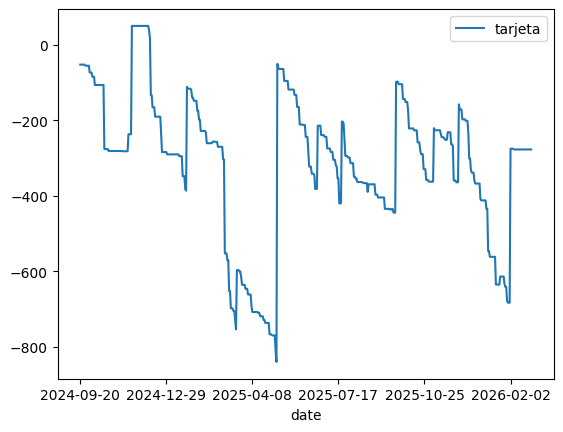

In [10]:
df.plot(x='date', y='tarjeta' )

In [8]:

res = requests.get(f"{API_BASE}/dashboard/variations")
data = res.json()

In [9]:
drivers=[x["top_drivers"] if "top_drivers" in x else [] for x in data]
drivers

[[{'description': '07550945-MASTERCARD     -RECAUDACIONES-223067000034',
   'amount': -401.21,
   'type': 'expense',
   'category': 'nan',
   'account': None,
   'source': 'BANCA',
   'date': '2024-09-20'},
  {'description': 'Valuación: Interpolado (Mensual_Madre)',
   'amount': 4.258064516129032,
   'type': 'interpolated_accrual',
   'category': None,
   'account': None,
   'source': 'INTERPOLADOS',
   'date': '2024-09-20'}],
 [{'description': 'Valuación: Interpolado (Mensual_Madre)',
   'amount': 4.258064516129032,
   'type': 'interpolated_accrual',
   'category': None,
   'account': None,
   'source': 'INTERPOLADOS',
   'date': '2024-09-21'}],
 [{'description': 'Valuación: Interpolado (Mensual_Madre)',
   'amount': 4.258064516129032,
   'type': 'interpolated_accrual',
   'category': None,
   'account': None,
   'source': 'INTERPOLADOS',
   'date': '2024-09-22'}],
 [{'description': 'COMISION PAGO TARJETA INTERBANCARIA ENVIADA',
   'amount': -0.34,
   'type': 'expense',
   'category':

In [ ]:
[driver for driver in drivers]

NameError: name 'driver' is not defined

In [10]:
[data.top_drivers if "top_drivers" in data else None for data in data]

AttributeError: 'dict' object has no attribute 'top_drivers'

In [179]:
[x.top_drives if "top_drives" in x else [] for x in data]

[[], [], []]

In [11]:
from contabilidad.backend.routes.dashboard import VariationsAnalyzer
from contabilidad.backend.routes.dashboard import DashboardService

In [39]:
ds =DashboardService()
df =ds.get_chart_data()
# df = pd.DataFrame(df.data)

INFO:contabilidad.backend.routes.dashboard:Fetching data from BankDataSource
INFO:contabilidad.backend.routes.dashboard:Fetching data from CardDataSource
INFO:contabilidad.backend.routes.dashboard:Fetching data from SupabaseDebtDataSource


✓ Cache hit: banca_data
✓ Cache hit: cuenta_data
✓ Cache hit: inversiones
✓ Cache hit: tarjetas


In [13]:
df= pd.DataFrame(data["data"])
df=df.rename(columns={"FECHA":"date","TARJETA":"tarjeta"})
df.head(30)

,date,total,saldo,saldo_sin_inversion,tarjeta,pagos_fijos,interpolado,notion,deuda_acumulada,diff_total,diff_tarjeta,diff_saldo_sin_inversion,diff_notion,diff_deuda_acumulada,diff_pagos_fijos,diff_interpolados
0,2024-09-20,-252.366774,10205.27,-280.73,-52.54,10486.0,80.903226,0.0,0.0,0.000000,0.00,0.00,0.0,0.0,0.0,0.000000
1,2024-09-21,-248.108710,10205.27,-280.73,-52.54,10486.0,85.161290,0.0,0.0,4.258065,0.00,0.00,0.0,0.0,0.0,4.258065
2,2024-09-22,-243.850645,10205.27,-280.73,-52.54,10486.0,89.419355,0.0,0.0,4.258065,0.00,0.00,0.0,0.0,0.0,4.258065
3,2024-09-23,345.907419,304.77,304.77,-52.54,0.0,93.677419,0.0,0.0,589.758065,0.00,585.50,0.0,0.0,-10486.0,4.258065
4,2024-09-24,350.165484,304.77,304.77,-52.54,0.0,97.935484,0.0,0.0,4.258065,0.00,0.00,0.0,0.0,0.0,4.258065
5,2024-09-25,354.423548,304.77,304.77,-52.54,0.0,102.193548,0.0,0.0,4.258065,0.00,0.00,0.0,0.0,0.0,4.258065
6,2024-09-26,346.841613,295.77,295.77,-55.38,0.0,106.451613,0.0,0.0,-7.581935,-2.84,-9.00,0.0,0.0,0.0,4.258065
7,2024-09-27,341.599677,286.27,286.27,-55.38,0.0,110.709677,0.0,0.0,-5.241935,0.00,-9.50,0.0,0.0,0.0,4.258065
8,2024-09-28,345.857742,286.27,286.27,-55.38,0.0,114.967742,0.0,0.0,4.258065,0.00,0.00,0.0,0.0,0.0,4.258065
9,2024-09-29,350.115806,286.27,286.27,-55.38,0.0,119.225806,0.0,0.0,4.258065,0.00,0.00,0.0,0.0,0.0,4.258065


In [38]:
dash_service = DashboardService()
dash_data_response = dash_service.get_chart_data()

# 2. Analyze Drivers
analyzer = VariationsAnalyzer()
analyzer.fetch_all_drivers()
analyzer.drivers_by_date

INFO:contabilidad.backend.routes.dashboard:Fetching data from BankDataSource
INFO:contabilidad.backend.routes.dashboard:Fetching data from CardDataSource


⚙ Loading: banca_data from XLSX
⚙ Loading: cuenta_data from Unified Banca Source
✓ Cache hit: banca_data
⚙ Executing: inversiones
Pago: 132.0 desde 2024-09-01 00:00:00 hasta 2024-10-02 00:00:00
Pago: 135.0 desde 2024-10-03 00:00:00 hasta 2024-11-05 00:00:00
Pago: 100.0 desde 2024-11-06 00:00:00 hasta 2025-01-01 00:00:00
Pago: 50.0 desde 2025-01-07 00:00:00 hasta 2025-02-24 00:00:00
Pago: 100.0 desde 2025-02-25 00:00:00 hasta 2025-03-21 00:00:00
Pago: 100.0 desde 2025-03-22 00:00:00 hasta 2025-04-23 00:00:00
Pago: 110.0 desde 2025-04-24 00:00:00 hasta 2025-05-22 00:00:00
Pago: 100.0 desde 2025-05-23 00:00:00 hasta 2025-06-24 00:00:00
Pago: 50.0 desde 2025-06-25 00:00:00 hasta 2025-07-28 00:00:00
Pago: 110.0 desde 2025-07-29 00:00:00 hasta 2025-09-22 00:00:00
Pago: 110.0 desde 2025-09-23 00:00:00 hasta 2025-11-06 00:00:00
Pago: 75.0 desde 2025-09-23 00:00:00 hasta 2025-11-06 00:00:00
Pago: 110.0 desde 2025-11-07 00:00:00 hasta 2025-11-24 00:00:00
Pago: 70.0 desde 2025-11-07 00:00:00 hast

INFO:contabilidad.backend.routes.dashboard:Fetching data from SupabaseDebtDataSource


⚙ Loading: tarjeta_unida_data from XLSX
ℹ LOGIC: Metadata < Bank. Anchor Pago: 2024-09-20 00:00:00. Meta Emision: 2024-09-06 00:00:00. Balance: 401.21
Pago: 401.21 desde 2024-09-20 hasta None
Pago: 45.11 desde 2024-11-15 hasta None
Pago: 286.98 desde 2024-11-19 hasta None
Pago: 20.0 desde 2025-01-21 hasta None
Pago: 275.27 desde 2025-01-22 hasta None
Pago: 29.52 desde 2025-02-21 hasta None
Pago: 20.0 desde 2025-03-21 hasta None
Pago: 309.55 desde 2025-03-21 hasta None
Pago: 30.27 desde 2025-04-21 hasta None
Pago: 789.73 desde 2025-05-07 hasta None
Pago: 20.0 desde 2025-06-23 hasta None
Pago: 216.1 desde 2025-06-23 hasta None
Pago: 20.0 desde 2025-07-21 hasta None
Pago: 248.82 desde 2025-07-21 hasta None
Pago: 20.0 desde 2025-08-21 hasta None
Pago: 409.71 desde 2025-09-22 hasta None
Pago: 20.0 desde 2025-10-21 hasta None
Pago: 141.95 desde 2025-11-05 hasta None
Pago: 20.0 desde 2025-11-21 hasta None
Pago: 206.37 desde 2025-12-04 hasta None
Pago: 163.72 desde 2025-12-16 hasta None
Pago: 

NameError: name 'VariationsAnalyzer' is not defined

In [62]:
from contabilidad.backend.routes.transactions import load_source_data

In [63]:
load_source_data()

✓ Cache hit: banca_data
✓ Cache hit: tarjeta_data


,id,FECHA,DESCRIPCION,MONTO,TIPO
0,03457e478ce9e157a2aa5776ed7ef1bb,2024-09-11 16:12:00,TRANSFERENCIA INTERBANCARIA A ANDRE SEBASTIAN ...,-3.75,BANCA
1,079ad73bfb7f624fd691eea3ba268344,2024-09-17 16:08:00,TRANSFERENCIA DIRECTA A ROMERO BENALCAZAR ALIC...,-6.50,BANCA
2,b19fe836a546131a92278988fb355928,2024-09-19 19:26:00,TRANSFERENCIA INTERBANCARIA A MARCELO ANDRES A...,-3.66,BANCA
3,185ea838e6809be86f2063f726af5824,2024-09-20 18:29:00,07550945-MASTERCARD -RECAUDACIONES-2230670...,-401.21,BANCA
4,09f424ad96cee7fab01dcbf0fff1cb3d,2024-09-23 11:51:00,COMISION PAGO TARJETA INTERBANCARIA ENVIADA,-0.34,BANCA
...,...,...,...,...,...
1333,da1591fc4e51c683b544b1c043e39b70,2026-02-02 00:00:00,UB *EATS ECUADOR 8,-5.47,TARJETA
1334,c1c94eba4f5f11b179f72ee5ff443f78,2026-02-02 00:00:00,RET IVA SERV DIGITAL 100%,-0.62,TARJETA
1335,1f33f5aef6423e390ea1134de3039ce8,2026-02-02 00:00:00,UBER *TRIP H,-4.15,TARJETA
1336,4651da39964ed788aad170bad676e295,2026-02-06 00:00:00,INT. FINANCIAMIENTO,-2.00,TARJETA


In [14]:
variations = VariationsAnalyzer()

In [43]:
dash_service = DashboardService()
dash_data_response = dash_service.get_chart_data()

# 2. Analyze Drivers
analyzer = VariationsAnalyzer()
analyzer.fetch_all_drivers()

# 3. Combine
analyze_df=analyzer.analyze(dash_data_response.data)

INFO:contabilidad.backend.routes.dashboard:Fetching data from BankDataSource
INFO:contabilidad.backend.routes.dashboard:Fetching data from CardDataSource
INFO:contabilidad.backend.routes.dashboard:Fetching data from SupabaseDebtDataSource


⚙ Loading: banca_data from XLSX
⚙ Loading: cuenta_data from Unified Banca Source
✓ Cache hit: banca_data
✓ Cache hit: inversiones
✓ Cache hit: tarjetas


ERROR:contabilidad.backend.routes.dashboard:Category 'Otro' found for transaction Hermana (-20.0). Marking as ERROR_OTRO.


✓ Cache hit: banca_data
⚙ Loading: tarjeta_data from Unified Tarjeta Source
⚙ Loading: tarjeta_unida_data from XLSX


In [59]:
# El orden correcto es: primero el padre, luego el hijo
resultado = [
    (driver.amount, driver.source) 
    for analyze in analyze_df 
    for driver in analyze.top_drivers
    if driver.source == 'TARJETA'

]
resultado

[(0.37, 'TARJETA'),
 (2.47, 'TARJETA'),
 (10.1, 'TARJETA'),
 (0.6, 'TARJETA'),
 (3.99, 'TARJETA'),
 (0.25, 'TARJETA'),
 (1.69, 'TARJETA'),
 (1.52, 'TARJETA'),
 (9.59, 'TARJETA'),
 (1.44, 'TARJETA'),
 (0.2, 'TARJETA'),
 (0.03, 'TARJETA'),
 (20.0, 'TARJETA'),
 (1.7, 'TARJETA'),
 (0.05, 'TARJETA'),
 (14.8, 'TARJETA'),
 (52.93, 'TARJETA'),
 (1.21, 'TARJETA'),
 (55.5, 'TARJETA'),
 (8.05, 'TARJETA'),
 (1.99, 'TARJETA'),
 (0.3, 'TARJETA'),
 (0.24, 'TARJETA'),
 (16.34, 'TARJETA'),
 (8.5, 'TARJETA'),
 (10.0, 'TARJETA'),
 (4.37, 'TARJETA'),
 (0.66, 'TARJETA'),
 (0.54, 'TARJETA'),
 (0.02, 'TARJETA'),
 (0.11, 'TARJETA'),
 (0.36, 'TARJETA'),
 (0.05, 'TARJETA'),
 (4.97, 'TARJETA'),
 (6.99, 'TARJETA'),
 (20.5, 'TARJETA'),
 (2.0, 'TARJETA'),
 (2.99, 'TARJETA'),
 (0.45, 'TARJETA'),
 (145.0, 'TARJETA'),
 (14.32, 'TARJETA'),
 (12.68, 'TARJETA'),
 (5.2, 'TARJETA'),
 (25.0, 'TARJETA'),
 (7.28, 'TARJETA'),
 (12.5, 'TARJETA'),
 (9.2, 'TARJETA'),
 (19.5, 'TARJETA'),
 (5.75, 'TARJETA'),
 (33.58, 'TARJETA'),
 (

<Axes: >

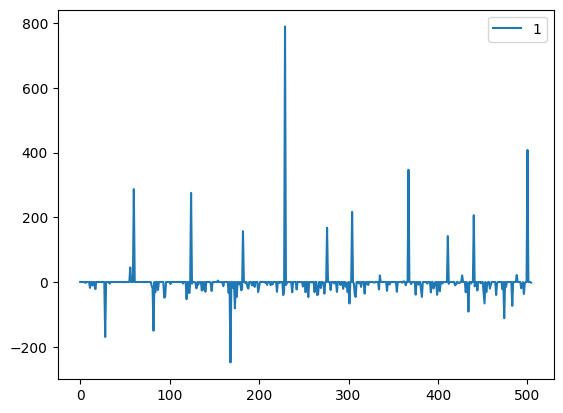

In [30]:
pd.DataFrame([(analyze.date, analyze.diff_tarjeta) for analyze in analyze_df]).plot()

In [15]:
variations.drivers_by_date

{}

In [153]:
pipeline = get_pipeline()
banca = pipeline.get_banca_data()
tarjeta = pipeline.get_tarjeta_data()

print(banca.head())
print(tarjeta.head())

⚙ Loading: banca_data from XLSX
⚙ Loading: tarjeta_data from Unified Tarjeta Source
⚙ Loading: tarjeta_unida_data from XLSX
                                 id               FECHA  \
0  03457e478ce9e157a2aa5776ed7ef1bb 2024-09-11 16:12:00   
1  079ad73bfb7f624fd691eea3ba268344 2024-09-17 16:08:00   
2  b19fe836a546131a92278988fb355928 2024-09-19 19:26:00   
3  185ea838e6809be86f2063f726af5824 2024-09-20 18:29:00   
4  09f424ad96cee7fab01dcbf0fff1cb3d 2024-09-23 11:51:00   

                                         DESCRIPCION   MONTO FUENTE     SALDO  
0  TRANSFERENCIA INTERBANCARIA A ANDRE SEBASTIAN ...   -3.75  BANCO  10616.64  
1  TRANSFERENCIA DIRECTA A ROMERO BENALCAZAR ALIC...   -6.50  BANCO  10610.14  
2  TRANSFERENCIA INTERBANCARIA A MARCELO ANDRES A...   -3.66  BANCO  10606.48  
3  07550945-MASTERCARD     -RECAUDACIONES-2230670... -401.21  BANCO  10205.27  
4        COMISION PAGO TARJETA INTERBANCARIA ENVIADA   -0.34  BANCO  10204.93  
                                 id      

<Axes: >

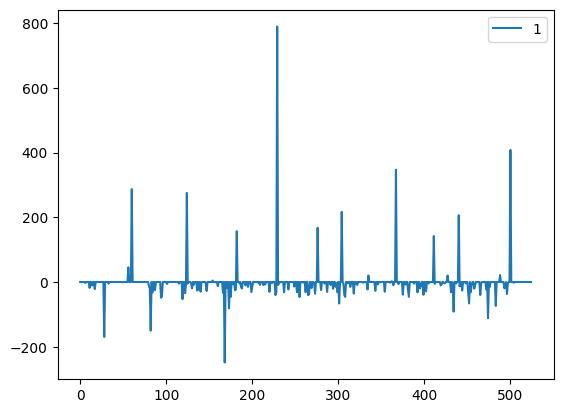

In [152]:
pd.DataFrame([(x["date"], x["diff_tarjeta"]) for x in data]).plot()

In [100]:
df.columns

Index(['date', 'total', 'saldo', 'saldo_sin_inversion', 'tarjeta',
       'pagos_fijos', 'interpolado', 'notion', 'deuda_acumulada', 'diff_total',
       'diff_tarjeta', 'diff_saldo_sin_inversion', 'diff_notion',
       'diff_deuda_acumulada'],
      dtype='object')

<Axes: xlabel='date'>

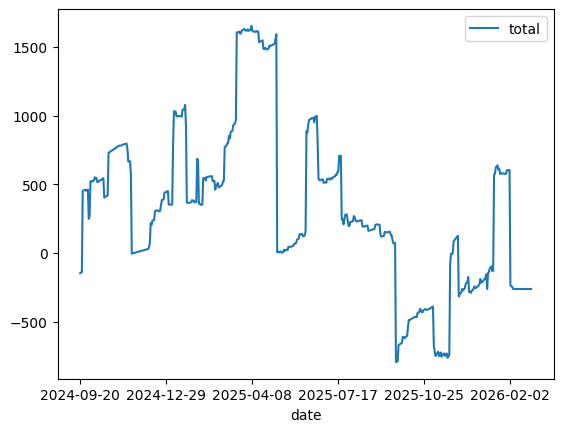

In [108]:
df.plot(x="date",y="total")

In [43]:
res = requests.get("http://localhost:8000/api/dashboard/variations")
res = res.json()
print(res)

[{'date': '2024-09-20', 'total_change': 0.0, 'diff_saldo_neto': 0.0, 'diff_tarjeta': 0.0, 'diff_notion': 0.0, 'diff_deuda_acumulada': 0.0, 'diff_pagos_fijos': 0.0, 'diff_interpolados': 0.0, 'top_drivers': [{'description': '07550945-MASTERCARD     -RECAUDACIONES-223067000034', 'amount': -401.21, 'type': 'expense', 'category': 'nan', 'account': None, 'source': 'BANCA', 'date': '2024-09-20'}, {'description': 'Valuación: Interpolado (Mensual_Madre)', 'amount': 4.258064516129032, 'type': 'interpolated_accrual', 'category': None, 'account': None, 'source': 'INTERPOLADOS', 'date': '2024-09-20'}], 'income_total': 4.258064516129032, 'expense_total': -401.21, 'unexplained_difference': 396.95193548387095}, {'date': '2024-09-21', 'total_change': 4.258064516129025, 'diff_saldo_neto': 0.0, 'diff_tarjeta': 0.0, 'diff_notion': 0.0, 'diff_deuda_acumulada': 0.0, 'diff_pagos_fijos': 0.0, 'diff_interpolados': 4.258064516129025, 'top_drivers': [{'description': 'Valuación: Interpolado (Mensual_Madre)', 'amo

In [44]:
drivers = [pago["top_drivers"] if "top_drivers" in pago else [] for pago in [dia for dia in res]]
drivers = [driver for lista in drivers for driver in lista]

In [45]:
drivers_dia = [driver for driver in drivers if driver['date']=="2025-01-06"]
drivers_dia

[{'description': 'COMISION PAGO TARJETA INTERBANCARIA ENVIADA',
  'amount': -0.34,
  'type': 'expense',
  'category': 'nan',
  'account': None,
  'source': 'BANCA',
  'date': '2025-01-06'},
 {'description': 'IVA COBRADO',
  'amount': -0.05,
  'type': 'expense',
  'category': 'nan',
  'account': None,
  'source': 'BANCA',
  'date': '2025-01-06'},
 {'description': 'PAGO TARJETA INTERBANCARIA ENVIADA',
  'amount': -1.26,
  'type': 'expense',
  'category': 'nan',
  'account': None,
  'source': 'BANCA',
  'date': '2025-01-06'},
 {'description': 'TRANSFERENCIA DIRECTA DE ARCINIEGA BASANTES PAULINA MARIA',
  'amount': 160.0,
  'type': 'income',
  'category': 'nan',
  'account': None,
  'source': 'BANCA',
  'date': '2025-01-06'},
 {'description': 'TRANSFERENCIA DIRECTA DE ARCINIEGA BASANTES PAULINA MARIA',
  'amount': 100.0,
  'type': 'income',
  'category': 'nan',
  'account': None,
  'source': 'BANCA',
  'date': '2025-01-06'},
 {'description': 'TRANSFERENCIA DIRECTA DE ARCINIEGA BASANTES PAU

In [50]:
[res_uniq for res_uniq in res if res_uniq["date"] == "2025-01-07"]


[{'date': '2025-01-07',
  'total_change': 259.99999999999994,
  'diff_saldo_neto': 239.99999999999994,
  'diff_tarjeta': 0.0,
  'diff_notion': 0.0,
  'diff_deuda_acumulada': 20.0,
  'diff_pagos_fijos': 0.0,
  'diff_interpolados': 0.0,
  'top_drivers': [{'description': 'TRANSFERENCIA DIRECTA A VILLACIS SUAREZ GABRIELA SOLEDAD',
    'amount': -6.0,
    'type': 'expense',
    'category': 'nan',
    'account': None,
    'source': 'BANCA',
    'date': '2025-01-07'},
   {'description': 'TRANSFERENCIA DIRECTA A LAVERDE MUÑOZ JORGE DAVID',
    'amount': -14.0,
    'type': 'expense',
    'category': 'nan',
    'account': None,
    'source': 'BANCA',
    'date': '2025-01-07'},
   {'description': 'Deuda: Gasolina (Madre)',
    'amount': 20.0,
    'type': 'debt',
    'category': None,
    'account': None,
    'source': 'DEUDA',
    'date': '2025-01-07'},
   {'description': 'Valuación: Interpolado (Mensual_Madre)',
    'amount': 1.0416666666666667,
    'type': 'interpolated_accrual',
    'category'

<Axes: xlabel='date'>

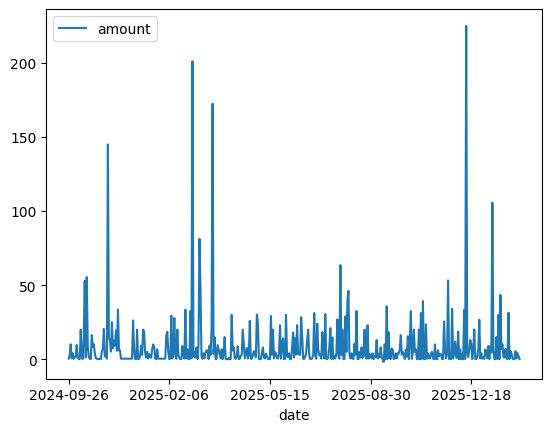

In [41]:
pd.DataFrame(drivers).query("source == 'TARJETA'").plot("date", "amount")


<Axes: xlabel='date'>

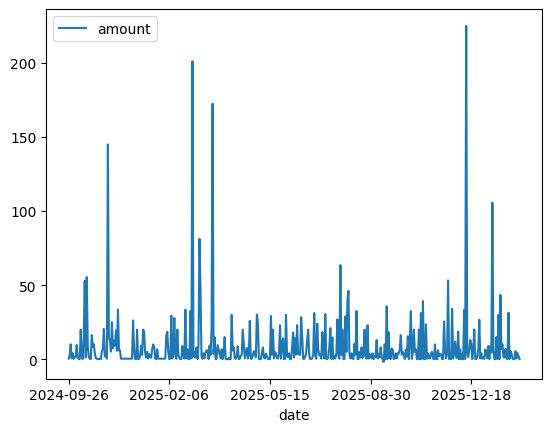

In [260]:
pd.DataFrame(drivers).query("source == 'TARJETA'").plot(x="date", y="amount")

<Axes: xlabel='date'>

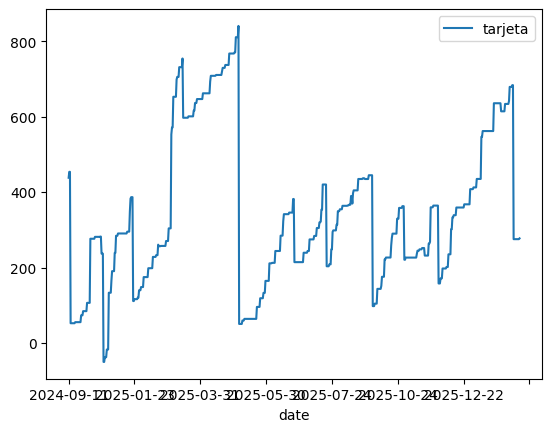

In [170]:
df.plot(x="date",y="tarjeta")